In [ ]:
# =========================
# PART 0 — IMPORTS & UTILs
# =========================

import numpy as np                   # math + arrays
import math                          # just for a few helpers
import random                        # not strictly needed, but handy
import matplotlib.pyplot as plt      # plotting (assignment-safe: no seaborn)

from collections import defaultdict  # for Q-table with default zeros


# ---- Simple moving average for learning curve ----
def moving_average(x, window=100):
    """
    Smooth noisy episode returns so the 'trend' is clear.
    Why? Each episode's return bounces around because of slip randomness.
    A moving average shows improvement more clearly.
    """
    if len(x) < window:
        return np.array(x, dtype=float)
    c = np.cumsum(np.array(x, dtype=float))
    c[window:] = c[window:] - c[:-window]
    return c[window-1:] / window


# ---- Utility to turn (x,y,z) into a single index and back (for Q table) ----
class Indexer3D:
    """
    Converts a coordinate (x,y,z) to a single integer index and back.
    Why? Q tables are simplest if we can store 'rows' by state index.
    """
    def __init__(self, W, H, D, obstacles, terminals):
        self.W, self.H, self.D = W, H, D
        # Build a list of VALID states (exclude obstacles)
        self.states = [(x,y,z)
                       for x in range(W) for y in range(H) for z in range(D)
                       if (x,y,z) not in obstacles]
        # Map each state to an integer index
        self.s2i = {s:i for i,s in enumerate(self.states)}
        self.i2s = {i:s for s,i in self.s2i.items()}

    def to_index(self, s):   # (x,y,z) -> int
        return self.s2i[s]

    def to_state(self, i):   # int -> (x,y,z)
        return self.i2s[i]


In [ ]:
# ===========================================
# PART 1 — 3D GRIDWORLD ENVIRONMENT (MDP)
# ===========================================

class Gridworld3D:
    """
    A slippery 3D grid game:
      - States: free cells (x,y,z)
      - Actions: 6 directions (±x, ±y, ±z)
      - Transitions: with prob p go intended; with 1-p slip to a perpendicular dir
      - Rewards: step_cost each step; +50 at goal (terminal); -50 at pit (terminal)
      - Obstacles: blocked cells you cannot enter (but game continues)
    """
    def __init__(self,
                 H=6, W=6, D=6,
                 slip_p=0.2,           # chance of NOT going where you intended
                 step_cost=-1.0,
                 gamma=0.95,
                 goal=(5,5,5),
                 pit=(2,2,2),
                 obstacle_ratio=0.12,  # about 10–15% obstacles (inside grid)
                 seed=42,
                 random_start=True,    # choose random start each episode?
                 fixed_start=(0,0,0)): # used if random_start=False
        self.H, self.W, self.D = H, W, D
        self.gamma = gamma
        self.step_cost = step_cost
        self.goal = tuple(goal)
        self.pit  = tuple(pit)
        self.random_start = random_start
        self.fixed_start = tuple(fixed_start)

        # Set up reproducible randomness
        self.rng = np.random.default_rng(seed)

        # Actions encoded as integer 0..5
        # Why numbers? Fast & simple table for Q[s,a]
        self._dirs = {
            0:(+1,0,0),  # +x (east)
            1:(-1,0,0),  # -x (west)
            2:(0,+1,0),  # +y (north)
            3:(0,-1,0),  # -y (south)
            4:(0,0,+1),  # +z (up floor)
            5:(0,0,-1),  # -z (down floor)
        }

        # For a given action, slips go to these 4 perpendicular directions
        self._perp_actions = {
            0:[2,3,4,5], 1:[2,3,4,5],
            2:[0,1,4,5], 3:[0,1,4,5],
            4:[0,1,2,3], 5:[0,1,2,3],
        }

        # Transition probabilities
        self.p_intended = 1.0 - slip_p
        self.p_slip_each = slip_p / 4.0  # four perpendicular options

        # Place obstacles once using the seed (reproducible layout)
        self.obstacles = self._place_obstacles(obstacle_ratio)

        # Terminals (absorbing)
        self.terminals = {self.goal, self.pit}

        # Basic safety: terminals must not be obstacles
        assert self.goal not in self.obstacles and self.pit not in self.obstacles

        # Build indexer for states so Q can be a (n_states x 6) array
        self.indexer = Indexer3D(self.W, self.H, self.D, self.obstacles, self.terminals)

        # Internal current state will be set by reset()
        self.state = None

    # ------------- bounds / blocks helpers -------------

    def _in_bounds(self, s):
        x,y,z = s
        return 0 <= x < self.W and 0 <= y < self.H and 0 <= z < self.D

    def _blocked(self, s):
        # Blocked if outside world OR an obstacle cube
        return (not self._in_bounds(s)) or (s in self.obstacles)

    def _place_obstacles(self, ratio):
        """
        Randomly mark ~ratio of the grid cells as obstacles,
        excluding goal and pit.
        """
        total = self.W * self.H * self.D
        n_obs = int(total * ratio)
        candidates = [(x,y,z)
                      for x in range(self.W) for y in range(self.H) for z in range(self.D)
                      if (x,y,z) not in {self.goal, self.pit}]
        self.rng.shuffle(candidates)
        return set(candidates[:n_obs])

    # ------------- public API -------------

    def reset(self):
        """
        Start a new episode:
          - If random_start: pick a random FREE, NON-terminal cell.
          - Else: use fixed_start (must be free & non-terminal).
        Returns the state (x,y,z).
        """
        if self.random_start:
            # list of free, non-terminal cells
            free = [(x,y,z)
                    for x in range(self.W) for y in range(self.H) for z in range(self.D)
                    if (x,y,z) not in self.obstacles and (x,y,z) not in self.terminals]
            self.state = free[self.rng.integers(len(free))]
        else:
            assert self.fixed_start not in self.obstacles and self.fixed_start not in self.terminals
            self.state = self.fixed_start
        return self.state

    def step(self, a):
        """
        Apply one action:
          - With prob p_intended go intended direction; else slip to a perpendicular.
          - If movement hits boundary/obstacle, you stay put.
          - Rewards: step_cost normally; +50 at goal; -50 at pit.
        Returns: (next_state, reward, done, info)
        """
        s = self.state

        # If already terminal, stay (absorbing)
        if s in self.terminals:
            self.state = s
            return s, 0.0, True, {}

        # Sample intended vs slip
        if self.rng.random() < self.p_intended:
            a_eff = a
        else:
            a_eff = random.choice(self._perp_actions[a])  # uniform among 4 perpendiculars

        # Compute candidate next cell
        dx,dy,dz = self._dirs[a_eff]
        ns = (s[0]+dx, s[1]+dy, s[2]+dz)

        # Blocked? then stay put
        if self._blocked(ns):
            ns = s

        # Rewards + termination
        if ns == self.goal:
            r, done = 50.0, True
        elif ns == self.pit:
            r, done = -50.0, True
        else:
            r, done = self.step_cost, False

        self.state = ns
        return ns, r, done, {}

    def sample_action(self):
        """Uniformly sample one of the 6 actions."""
        return int(self.rng.integers(6))

    def greedy_action_from_Q(self, Q, s):
        """
        Pick the action with max Q-value at state s.
        Ties broken by argmax semantics (first max).
        """
        si = self.indexer.to_index(s)
        return int(np.argmax(Q[si]))

    # ---------- visualization helpers: 2D slice per z ----------
    def slice_codes(self, z_level):
        """
        Return a 2D array (H x W) for floor z_level with codes:
            0 free, -1 obstacle, +2 goal, -2 pit
        Useful to overlay arrows later.
        """
        grid = np.zeros((self.H, self.W), dtype=int)
        for x in range(self.W):
            for y in range(self.H):
                s = (x,y,z_level)
                if s in self.obstacles:
                    grid[y, x] = -1
        gx,gy,gz = self.goal
        if gz == z_level: grid[gy, gx] = 2
        px,py,pz = self.pit
        if pz == z_level: grid[py, px] = -2
        return grid


In [ ]:
# ===========================================
# PART 2 — Q-LEARNING (TRAINING)
# ===========================================

def q_learning_train(env,
                     episodes=5000,          # how many episodes to learn
                     alpha=0.1,              # learning rate
                     epsilon_start=1.0,      # start fully exploring
                     epsilon_end=0.05,       # end with little exploration
                     epsilon_decay_ratio=0.7,# fraction of training used to decay epsilon
                     max_steps=500):         # safety cap per episode
    """
    Learn Q[s,a] by interacting with env over many episodes.
    - epsilon-greedy: 'usually best action, sometimes random' to explore.
    - alpha: how big a step to take on each update.
    - gamma: comes from env (env.gamma).
    Returns:
        Q (numpy array shape [n_states, 6]),
        returns_per_episode (list of total rewards),
        epsilons (list of epsilon values)
    """
    n_states = len(env.indexer.states)
    n_actions = 6
    Q = np.zeros((n_states, n_actions), dtype=float)  # start optimistic? here we use zeros

    returns = []
    epsilons = []

    # Plan epsilon schedule: decay from start to end over some fraction of episodes
    decay_episodes = int(episodes * epsilon_decay_ratio)
    def epsilon_at(ep):
        if ep < decay_episodes:
            # linear decay
            return epsilon_start - (epsilon_start - epsilon_end) * (ep / max(1, decay_episodes))
        else:
            return epsilon_end

    for ep in range(episodes):
        s = env.reset()
        total = 0.0
        eps = epsilon_at(ep)
        epsilons.append(eps)

        for t in range(max_steps):
            si = env.indexer.to_index(s)

            # --- ε-greedy action selection ---
            if np.random.random() < eps:
                a = env.sample_action()   # explore
            else:
                a = int(np.argmax(Q[si])) # exploit

            s2, r, done, _ = env.step(a)
            total += r

            # --- Q-learning update ---
            si2 = env.indexer.to_index(s2)
            best_next = np.max(Q[si2])
            td_target = r + env.gamma * best_next
            td_error  = td_target - Q[si, a]
            Q[si, a] += alpha * td_error

            s = s2
            if done:
                break

        returns.append(total)

    return Q, returns, epsilons


In [ ]:
# ===========================================
# PART 3 — EVALUATION & BASELINE (100 EPs)
# ===========================================

def run_episodes(env, policy_fn, episodes=100, max_steps=500):
    """
    Run multiple test episodes with a fixed policy (no learning).
    Return:
      avg_return, success_rate, avg_steps
    """
    rets = []
    steps_list = []
    successes = 0

    for _ in range(episodes):
        s = env.reset()
        total = 0.0
        steps = 0
        for t in range(max_steps):
            a = policy_fn(env, s)
            s, r, done, _ = env.step(a)
            total += r
            steps += 1
            if done:
                if s == env.goal:
                    successes += 1
                break
        rets.append(total)
        steps_list.append(steps)

    return (float(np.mean(rets)),
            successes / episodes,
            float(np.mean(steps_list)))


# ---- Greedy policy from learned Q ----
def greedy_policy_from_Q(Q):
    def policy(env, s):
        si = env.indexer.to_index(s)
        return int(np.argmax(Q[si]))
    return policy


# ---- Random policy baseline ----
def random_policy(env, s):
    return env.sample_action()


In [ ]:
# ===========================================
# PART 4 — VISUALIZATION HELPERS
# ===========================================

def plot_learning_curve(returns, window=100):
    """
    Plot raw episode returns (light) and moving average (bold).
    Viva point: show improvement over time.
    """
    plt.figure(figsize=(7,4))
    plt.plot(returns, alpha=0.4, label='Episode returns')
    ma = moving_average(returns, window=window)
    # Align x for moving average
    xs = np.arange(len(ma)) + (window-1)
    plt.plot(xs, ma, linewidth=2, label=f'Moving average ({window})')
    plt.xlabel('Episode')
    plt.ylabel('Return (sum of rewards)')
    plt.title('Learning curve')
    plt.legend()
    plt.tight_layout()
    plt.show()


def draw_policy_slice(env, Q, z_level):
    """
    For one floor (z_level), show:
      - heat: V(s) = max_a Q(s,a) for free cells
      - arrows: greedy action for each free cell
      - marks: obstacles, goal, pit
    """
    grid = env.slice_codes(z_level)  # codes: 0 free, -1 obstacle, +2 goal, -2 pit

    # Build value map for free cells on this floor
    V = np.full((env.H, env.W), np.nan)
    AX = np.full((env.H, env.W), 0)  # store greedy action for arrows

    for x in range(env.W):
        for y in range(env.H):
            s = (x,y,z_level)
            if s in env.obstacles:
                continue
            # value only if it's a valid state
            try:
                si = env.indexer.to_index(s)
            except KeyError:
                continue
            V[y,x] = np.max(Q[si])
            AX[y,x] = int(np.argmax(Q[si]))

    # Plot heatmap of V with imshow
    plt.figure(figsize=(5,5))
    plt.imshow(V, origin='lower', interpolation='nearest')
    plt.colorbar(label='Value: max_a Q(s,a)')
    plt.title(f'Floor z={z_level}: value & greedy arrows')
    plt.xlabel('x (columns)')
    plt.ylabel('y (rows)')

    # Draw obstacles/goal/pit overlays
    for x in range(env.W):
        for y in range(env.H):
            code = grid[y,x]
            if code == -1:
                # obstacles as squares with an 'X'
                plt.text(x, y, 'X', ha='center', va='center')
            elif code == 2:
                plt.text(x, y, 'G', ha='center', va='center', fontweight='bold')
            elif code == -2:
                plt.text(x, y, 'P', ha='center', va='center', fontweight='bold')

    # Draw arrows for greedy actions on free cells
    # Action vectors for quiver: (dx, dy)
    dir2vec = {
        0:(+1,0), 1:(-1,0), 2:(0,+1), 3:(0,-1), 4:(0,0), 5:(0,0)
        # Note: Up/Down in z (4/5) we can't show in a 2D slice, so draw no arrow.
    }
    Xs, Ys, Us, Vs = [], [], [], []
    for x in range(env.W):
        for y in range(env.H):
            if np.isnan(V[y,x]):
                continue
            a = AX[y,x]
            u, v = dir2vec[a]
            Xs.append(x)
            Ys.append(y)
            Us.append(u)
            Vs.append(v)

    plt.quiver(Xs, Ys, Us, Vs, angles='xy', scale_units='xy', scale=1)
    plt.tight_layout()
    plt.show()


Environment ready: W,H,D=(6,6,6), obstacles=25, goal=(5, 5, 5), pit=(2, 2, 2)


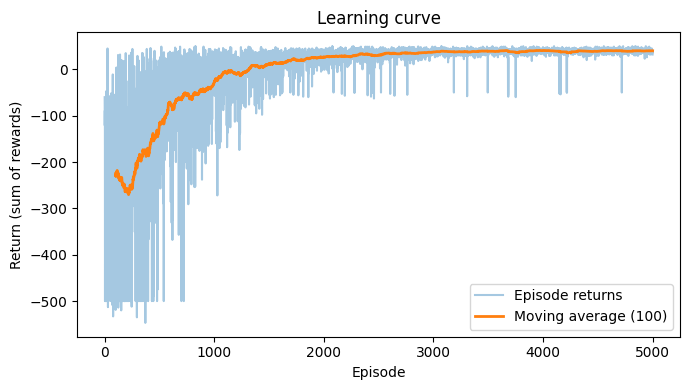


== Learned policy (greedy) over 100 episodes ==
Average return: 40.41
Success rate (reach goal): 100.0%
Average steps to finish: 10.6

== Random policy baseline over 100 episodes ==
Average return: -243.13
Success rate (reach goal): 14.0%
Average steps to finish: 214.0


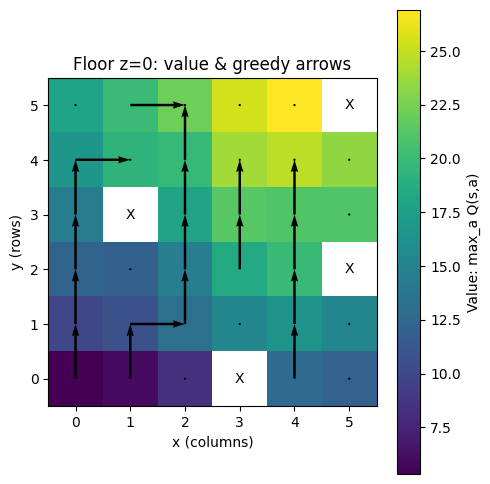

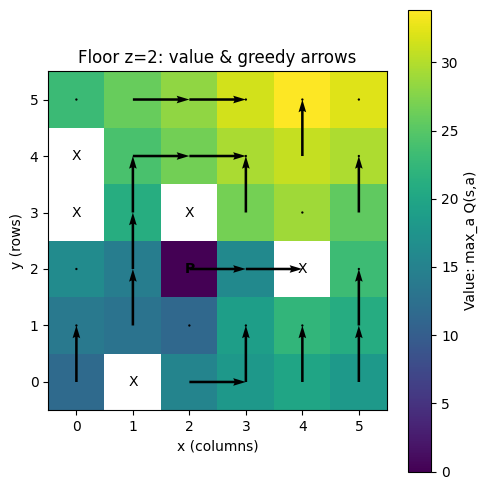

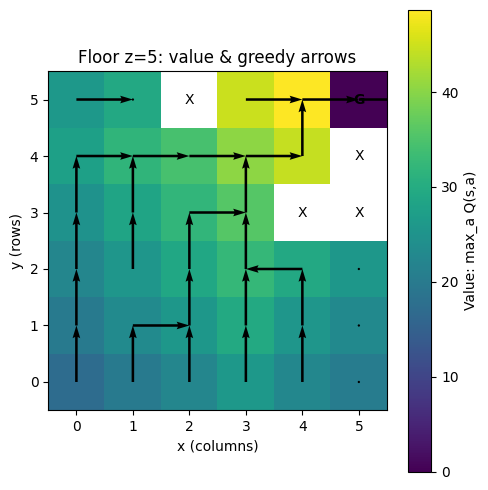

In [ ]:
# ===========================================
# PART 5 — RUN EVERYTHING (MAIN)
# ===========================================

# ---- 5.1 Build ONE environment (fixed world for this experiment) ----
env = Gridworld3D(
    H=6, W=6, D=6,        # grid size (assignment default)
    slip_p=0.2,           # stochasticity
    step_cost=-1.0,       # penalty per move
    gamma=0.95,           # discount factor
    goal=(5,5,5),         # fixed terminals; change if you want
    pit=(2,2,2),
    obstacle_ratio=0.12,  # about 12% of cells are obstacles
    seed=42,              # FIXED seed -> reproducible map & randomness
    random_start=True,    # random start each episode (common choice)
    fixed_start=(0,0,0)   # ignored if random_start=True
)

print("Environment ready:",
      f"W,H,D=({env.W},{env.H},{env.D}),",
      f"obstacles={len(env.obstacles)},",
      f"goal={env.goal}, pit={env.pit}")


# ---- 5.2 Train Q-learning ----
Q, ep_returns, epsilons = q_learning_train(
    env,
    episodes=5000,          # tuneable; more episodes -> better policy (but slower)
    alpha=0.1,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay_ratio=0.7,
    max_steps=500
)

# ---- 5.3 Plot learning curve ----
plot_learning_curve(ep_returns, window=100)


# ---- 5.4 Evaluate learned policy (ε=0 greedy) over 100 episodes ----
greedy_pol = greedy_policy_from_Q(Q)
avg_ret, success_rate, avg_steps = run_episodes(env, greedy_pol, episodes=100, max_steps=500)

print("\n== Learned policy (greedy) over 100 episodes ==")
print(f"Average return: {avg_ret:.2f}")
print(f"Success rate (reach goal): {100*success_rate:.1f}%")
print(f"Average steps to finish: {avg_steps:.1f}")


# ---- 5.5 Baseline: random policy over 100 episodes ----
avg_ret_r, success_rate_r, avg_steps_r = run_episodes(env, random_policy, episodes=100, max_steps=500)

print("\n== Random policy baseline over 100 episodes ==")
print(f"Average return: {avg_ret_r:.2f}")
print(f"Success rate (reach goal): {100*success_rate_r:.1f}%")
print(f"Average steps to finish: {avg_steps_r:.1f}")


# ---- 5.6 Visualize a couple of floors (slices) ----
# Pick some z-levels that include the pit/goal floors to be informative:
z_levels = sorted({env.goal[2], env.pit[2], 0, env.D-1})
z_levels = [z for z in z_levels if 0 <= z < env.D]

for z in z_levels:
    draw_policy_slice(env, Q, z)
